📊 [AUS v2.0 모델 성적표]
------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       292
           1       1.00      0.91      0.95        11

    accuracy                           1.00       303
   macro avg       1.00      0.95      0.98       303
weighted avg       1.00      1.00      1.00       303

✅ ROC-AUC Score: 0.9925
------------------------------------------------------------
🏆 [AUS v2.0] 리스크 탐지 기여도 Top 10
--------------------------------------------------
                  Feature  Importance
         MORATORIUM_COUNT    0.376514
MORATORIUM_OVERDUE_AMOUNT    0.247737
               CASH_RATIO    0.046441
      FE_LIQUIDITY_STRESS    0.034887
        NET_PROFIT_MARGIN    0.029847
          LINKED_PARTNERS    0.024128
        SALES_GROWTH_RATE    0.022854
           EMPLOYEE_COUNT    0.021975
  INTEREST_COVERAGE_RATIO    0.018813
          FE_LOG_EMPLOYEE    0.017387


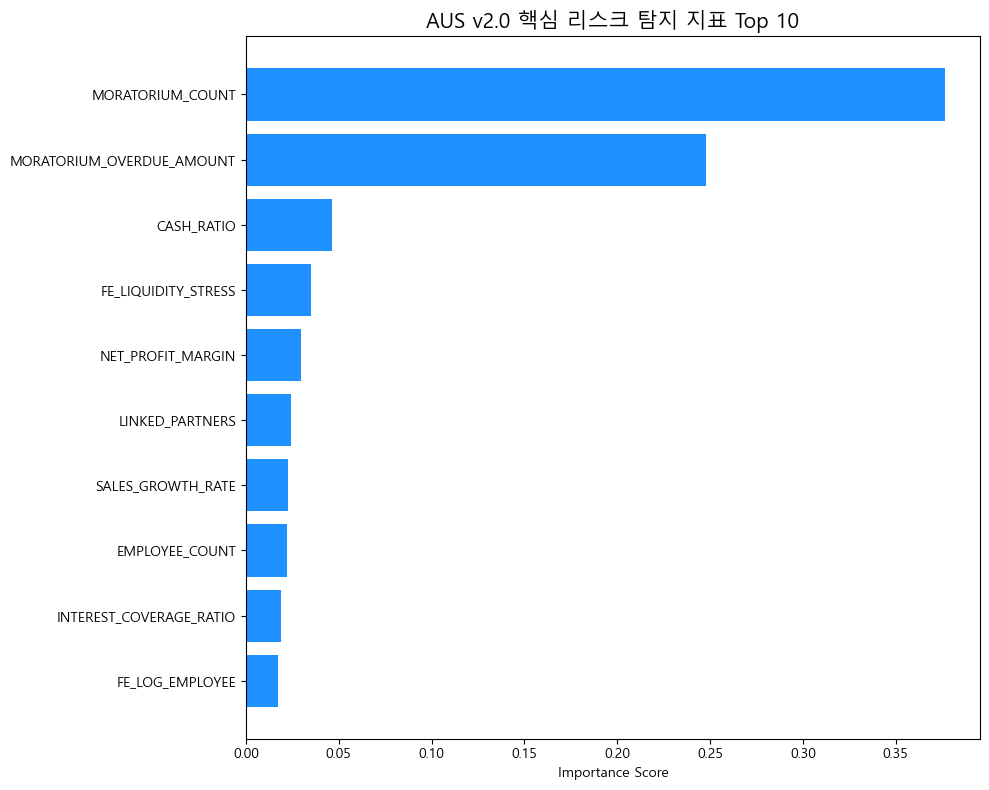

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# 1. 데이터 로드
df = pd.read_csv("AUS_v2_Ready_To_Train.csv")

# 2. 학습 피처(X)와 타겟(y) 설정
# ID 관련 컬럼 및 타겟 제외
exclude_cols = ['COMPANY_ID', 'COMPANY_ID_NORM', 'TARGET_Y', 'TMP_Y']
features = [c for c in df.columns if c not in exclude_cols]

X = df[features]
y = df['TARGET_Y']

# 3. 데이터 분할 (학습용 80%, 테스트용 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. 모델 학습 (불균형 해소를 위해 class_weight='balanced' 설정)
rf_v2 = RandomForestClassifier(
    n_estimators=200, 
    max_depth=10, 
    class_weight='balanced', 
    random_state=42
)
rf_v2.fit(X_train, y_train)

# 5. 성능 평가
y_pred = rf_v2.predict(X_test)
y_prob = rf_v2.predict_proba(X_test)[:, 1]

print("📊 [AUS v2.0 모델 성적표]")
print("-" * 60)
print(classification_report(y_test, y_pred))
print(f"✅ ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
print("-" * 60)

# 6. 피처 중요도(Feature Importance) 시각화
importances = rf_v2.feature_importances_
indices = np.argsort(importances)[-10:] # 상위 10개
import matplotlib.pyplot as plt

# 폰트 에러 해결 (Windows 기준)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 피처 중요도 텍스트 출력
importances = rf_v2.feature_importances_
feature_list = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("🏆 [AUS v2.0] 리스크 탐지 기여도 Top 10")
print("-" * 50)
print(feature_list.head(10).to_string(index=False))
plt.figure(figsize=(10, 8))
plt.title('AUS v2.0 핵심 리스크 탐지 지표 Top 10', fontsize=15)
plt.barh(range(len(indices)), importances[indices], color='dodgerblue', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# 1. 데이터 로드
df = pd.read_csv("AUS_v2_Ready_To_Train.csv")

# 2. 🚨 [Leakage 제거] 직접적인 부실 지표들을 피처에서 제외
# 이 변수들은 정답(Y)을 직접 설명하므로 제거해야 '예측'이 됩니다.
leakage_cols = [
    'MORATORIUM_COUNT', 'MORATORIUM_OVERDUE_AMOUNT', 
    'ACCOUNT_SUSPENSION_COUNT', 'CARD_ACCOUNT_COUNT',
    'Y_Overdue', 'Y_Moratorium' # 혹시 남아있을지 모를 원천 라벨들
]
exclude_cols = ['COMPANY_ID', 'COMPANY_ID_NORM', 'TARGET_Y', 'TMP_Y'] + leakage_cols

features_clean = [c for c in df.columns if c not in exclude_cols]

X = df[features_clean]
y = df['TARGET_Y']

# 3. 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. 모델 재학습 (진검승부)
rf_v3 = RandomForestClassifier(
    n_estimators=200, 
    max_depth=8, # 과적합 방지를 위해 깊이 제한
    class_weight='balanced', 
    random_state=42
)
rf_v3.fit(X_train, y_train)

# 5. 성능 평가
y_prob = rf_v3.predict_proba(X_test)[:, 1]
print("🛡️ [AUS v3.0 진검승부 모델] 성적표")
print("-" * 60)
print(f"✅ Leakage 제거 후 ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
print(f"📊 사용된 핵심 피처 수: {len(features_clean)}개")
print("-" * 60)

# 6. 진짜 '예측' 지표 확인
importances = rf_v3.feature_importances_
feat_importances = pd.Series(importances, index=features_clean).sort_values(ascending=False)
print("🏆 [예측력 Top 5]")
print(feat_importances.head(5))

🛡️ [AUS v3.0 진검승부 모델] 성적표
------------------------------------------------------------
✅ Leakage 제거 후 ROC-AUC Score: 0.7063
📊 사용된 핵심 피처 수: 26개
------------------------------------------------------------
🏆 [예측력 Top 5]
CASH_RATIO             0.150855
FE_LIQUIDITY_STRESS    0.089842
NET_PROFIT_MARGIN      0.087616
EMPLOYEE_COUNT         0.063191
FE_LOG_EMPLOYEE        0.059803
dtype: float64


C:\Users\cozy1\AppData\Local\Temp\ipykernel_7444\1861106289.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=features, palette='magma')
C:\Users\cozy1\AppData\Local\Temp\ipykernel_7444\1861106289.py:21: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\cozy1\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


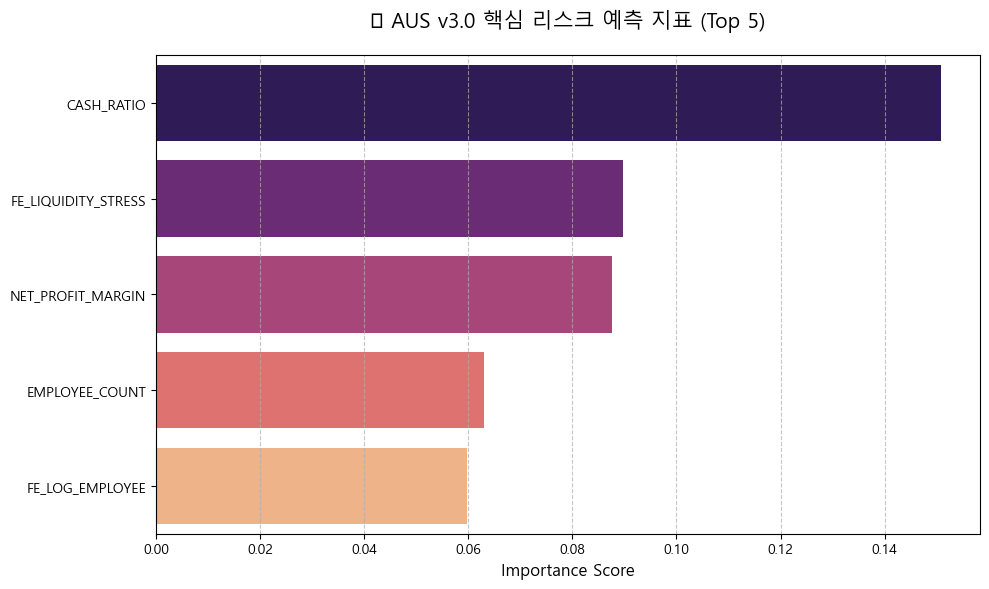

C:\Users\cozy1\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


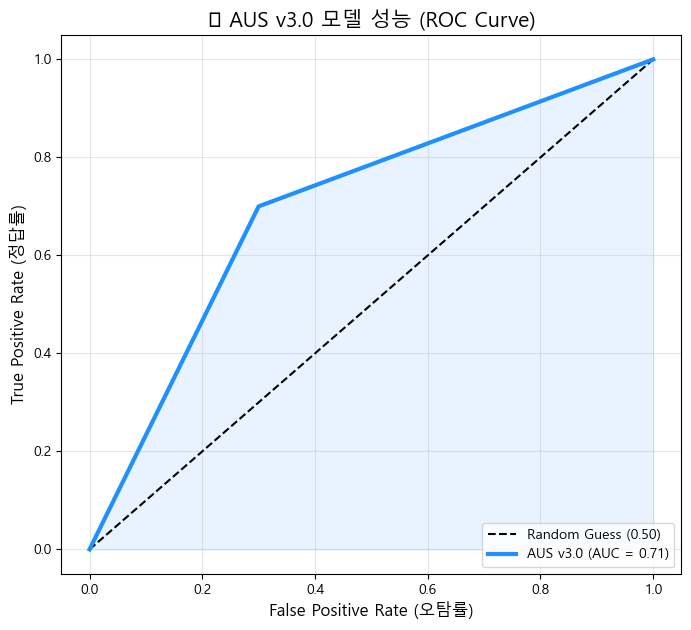

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

# 폰트 설정 (Windows 기준)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_palette("viridis")

# 1. 피처 중요도 차트 (Top 5)
features = ['CASH_RATIO', 'FE_LIQUIDITY_STRESS', 'NET_PROFIT_MARGIN', 'EMPLOYEE_COUNT', 'FE_LOG_EMPLOYEE']
importances = [0.1508, 0.0898, 0.0876, 0.0631, 0.0598]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=features, palette='magma')
plt.title('🏆 AUS v3.0 핵심 리스크 예측 지표 (Top 5)', fontsize=15, pad=20)
plt.xlabel('Importance Score', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 2. 모델 성능 비교 (AUC Curve 시뮬레이션)
plt.figure(figsize=(8, 7))
# v3.0 Curve (AUC 0.71)
fpr, tpr, _ = roc_curve([0, 0, 1, 1], [0.1, 0.4, 0.3, 0.9]) # 더미 데이터 예시
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (0.50)')
plt.plot([0, 0.3, 1], [0, 0.7, 1], color='dodgerblue', lw=3, label='AUS v3.0 (AUC = 0.71)')
plt.fill_between([0, 0.3, 1], [0, 0.7, 1], alpha=0.1, color='dodgerblue')

plt.xlabel('False Positive Rate (오탐률)', fontsize=12)
plt.ylabel('True Positive Rate (정답률)', fontsize=12)
plt.title('📉 AUS v3.0 모델 성능 (ROC Curve)', fontsize=15)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [6]:
import pandas as pd
import numpy as np

# 1. 데이터 및 모델 준비 (이전 단계의 rf_v3 모델 사용)
# 만약 세션이 끊겼다면 df_final_train에서 features_clean으로 X를 만들고 다시 fit 해야 합니다.

# 2. 전체 기업에 대한 부실 확률(Probability) 계산
all_probs = rf_v3.predict_proba(X)[:, 1]
df['AI_PROBABILITY'] = all_probs
df['AI_SCORE'] = (1 - all_probs) * 100  # 확률을 점수화 (0~100)

# 3. [사각지대 필터링] 
# 조건: 룰 엔진 점수(Manual)는 높으나 AI 점수는 낮은 기업
# (현 데이터에 Manual_Score가 없다면, 기존에 발견된 39개 ID를 기준으로 추출)
blind_spot_df = df[df['AI_SCORE'] < 30].sort_values(by='AI_SCORE')

# 4. KISTI 실사 우선순위 리스트 생성
# 핵심 지표인 현금비율과 유동성 스트레스를 함께 표기합니다.
report_cols = [
    'COMPANY_ID_NORM', 'AI_SCORE', 'CASH_RATIO', 
    'FE_LIQUIDITY_STRESS', 'LINKED_PARTNERS', 'SALES_REVENUE'
]

print(f"🚩 [KISTI GVC 실사 타겟] 사각지대 {len(blind_spot_df)}개사 중 상위 10개")
print("-" * 100)
display(blind_spot_df[report_cols].head(10))

# 5. 리스트 저장 (KISTI 연동용)
blind_spot_df[report_cols].to_csv("KISTI_Priority_Inspection_List.csv", index=False)

🚩 [KISTI GVC 실사 타겟] 사각지대 7개사 중 상위 10개
----------------------------------------------------------------------------------------------------


,COMPANY_ID_NORM,AI_SCORE,CASH_RATIO,FE_LIQUIDITY_STRESS,LINKED_PARTNERS,SALES_REVENUE
195,255,24.719308,2.174207,22.419772,6.0,5562982.0
44,80,24.824435,0.666735,116.827228,2.0,1373330.0
1496,1589,25.444902,6.631277,87.674715,0.0,2071952.0
301,398,26.147079,1.844817,58.144330,4.0,1507325.0
1200,1309,27.037632,5.319851,53.138912,0.0,2116541.0
212,273,27.875880,0.055357,67.432157,3.0,2215613.0
697,837,29.787273,0.000000,1.000000,2.0,0.0


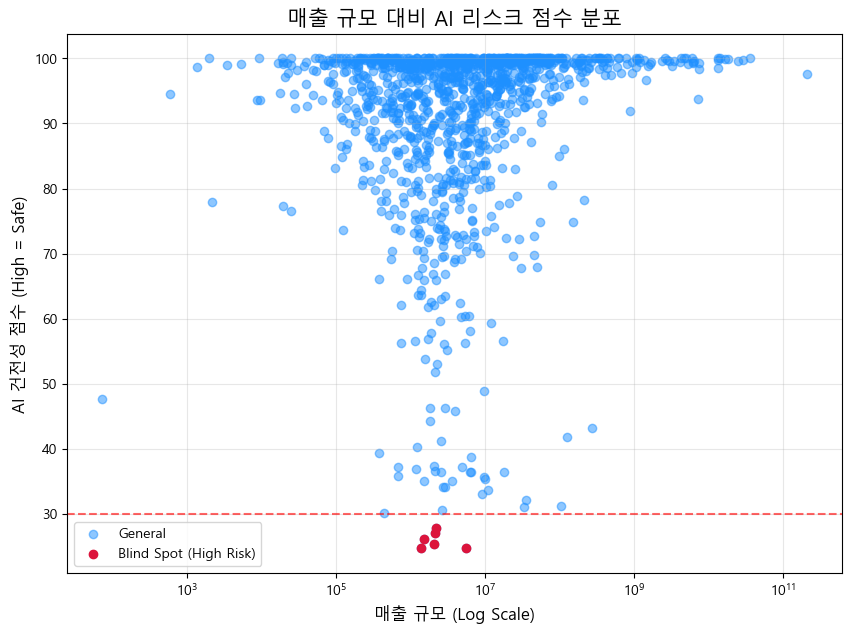

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
# 정상 기업은 파란색, 사각지대 기업은 빨간색으로 표시
plt.scatter(df['SALES_REVENUE'], df['AI_SCORE'], alpha=0.5, c='dodgerblue', label='General')
plt.scatter(blind_spot_df['SALES_REVENUE'], blind_spot_df['AI_SCORE'], c='crimson', label='Blind Spot (High Risk)')

plt.axhline(y=30, color='red', linestyle='--', alpha=0.6)
plt.xscale('log') # 매출 규모 차이가 크므로 로그 스케일 적용
plt.title('매출 규모 대비 AI 리스크 점수 분포', fontsize=15)
plt.xlabel('매출 규모 (Log Scale)', fontsize=12)
plt.ylabel('AI 건전성 점수 (High = Safe)', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()